# Adquisición y descriptores de imágenes

Integrantes:
* Daniel Jiménez Sánchez
* Axel Roman Vázquez Pelayo
* Rodrigo Peña Muñoz
* Cynthia Gabriela González Rayas

En este notebook:

1. Cargamos las imágenes de los dos datasets (`Animales` y `Materiales`).
2. Construimos un descriptor propio para cada dataset, usando operaciones básicas vistas en clase (histogramas, estadísticas globales, zonas, diferencias entre vecinos). No se usan descriptores avanzados predefinidos.
3. Calculamos la matriz de distancias entre todas las imágenes de cada dataset.
4. Graficamos cada matriz como un mapa de calor, ordenando las imágenes por categoría para que las de la misma clase queden contiguas.

Para cada dataset se usa un descriptor y una distancia distintos, ya que la naturaleza de los datos es diferente. `Animales` son fotografías a color (el color ayuda a distinguir gato de perro), mientras que `Materiales` son texturas donde lo relevante no es el color sino el patrón espacial de intensidades.

## 1. Preparación (descomprimir el dataset)

Coloca el archivo `ImagenesDescriptor.zip` en la misma carpeta que este notebook y ejecuta la siguiente celda. Si la carpeta `ImagenesDescriptor` ya existe, este paso se omite.

In [11]:
import os
import zipfile

ZIP_PATH = "ImagenesDescriptor.zip"
DATA_DIR = "ImagenesDescriptor"

if not os.path.exists(DATA_DIR):
    if os.path.exists(ZIP_PATH):
        with zipfile.ZipFile(ZIP_PATH, "r") as z:
            z.extractall(".")
        print("Dataset descomprimido correctamente.")
    else:
        raise FileNotFoundError(
            f"No se encontró ni '{DATA_DIR}' ni '{ZIP_PATH}'. "
            "Coloca el zip en esta carpeta y vuelve a ejecutar la celda."
        )
else:
    print("La carpeta ya existe, no es necesario descomprimir.")


La carpeta ya existe, no es necesario descomprimir.


## 2. Imports

In [21]:
import glob

import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color


## 3. Función genérica para cargar imágenes

Cargamos las imágenes carpeta por carpeta, en un orden fijo. Esto es clave para que, más adelante, las imágenes de una misma categoría queden en posiciones contiguas dentro de la matriz de distancias.

In [30]:
def cargar_imagenes(base_path, categorias, extension):
    """
    Carga todas las imágenes de una lista de categorías (subcarpetas),
    respetando el orden de la lista para que queden contiguas por clase.

    Regresa:
        imagenes: lista de arreglos numpy (una por imagen)
        etiquetas: lista de strings con el nombre de la categoría de cada imagen
    """
    imagenes = []
    etiquetas = []
    for categoria in categorias:
        carpeta = os.path.join(base_path, categoria)
        archivos = sorted(glob.glob(os.path.join(carpeta, f"*.{extension}")))
        for archivo in archivos:
            img = io.imread(archivo)
            imagenes.append(img)
            etiquetas.append(categoria)
    print(f"{len(imagenes)} imágenes cargadas de {base_path}")
    return imagenes, etiquetas


## 4. Distancias y mapa de calor

Implementamos la distancia Euclidiana y la distancia Manhattan, y una función para graficar la matriz de distancias como mapa de calor marcando los límites entre categorías.

In [31]:
def distancia_euclidiana(a, b):
    return np.sqrt(np.sum((a - b) ** 2))


def distancia_manhattan(a, b):
    return np.sum(np.abs(a - b))


def matriz_distancias(descriptores, funcion_distancia):
    """
    Calcula la matriz de distancias (n x n) entre todos los pares de
    descriptores usando la función de distancia indicada.
    """
    n = len(descriptores)
    D = np.zeros((n, n))
    for i in range(n):
        for j in range(i, n):
            d = funcion_distancia(descriptores[i], descriptores[j])
            D[i, j] = d
            D[j, i] = d  # la distancia es simétrica
    return D


def graficar_heatmap(D, etiquetas, titulo):
    """
    Grafica la matriz de distancias como mapa de calor. Como las imágenes
    están ordenadas por categoría, se dibujan líneas que marcan dónde
    termina una categoría y empieza la siguiente.
    """
    plt.figure(figsize=(7, 6))
    plt.imshow(D, cmap="viridis")
    plt.colorbar(label="Distancia")
    plt.title(titulo)
    plt.xlabel("Índice de imagen")
    plt.ylabel("Índice de imagen")

    # Líneas divisorias entre categorías
    cambios = [i for i in range(1, len(etiquetas)) if etiquetas[i] != etiquetas[i - 1]]
    for c in cambios:
        plt.axhline(c - 0.5, color="red", linewidth=1)
        plt.axvline(c - 0.5, color="red", linewidth=1)

    plt.tight_layout()
    plt.show()


## 5. Dataset 1. Animales (cats / Dogs)

**Descriptor elegido: histograma de color RGB.**

Como cats y Dogs son fotografías a color, el color es una señal simple y razonable para distinguirlas. Concatenamos el histograma normalizado de cada canal (R, G, B) en un solo vector, igual que se vio en clase.

**Distancia elegida: Euclidiana (L2).**

In [38]:
base_animales = os.path.join(DATA_DIR, "Animales")
categorias_animales = ["cats", "Dogs"]

imgs_animales, labels_animales = cargar_imagenes(base_animales, categorias_animales, extension="jpg")


20 imágenes cargadas de ImagenesDescriptor/Animales


In [44]:
def descriptor_color_rgb(img, bins=32):
    """
    Descriptor propio para imágenes a color: histograma normalizado
    de cada canal RGB, concatenado en un solo vector.
    """
    if img.ndim == 2:  # por si alguna imagen viniera en escala de grises
        img = color.gray2rgb(img)
    if img.shape[2] == 4:  # por si tuviera canal alpha
        img = img[:, :, :3]

    R, G, B = img[:, :, 0], img[:, :, 1], img[:, :, 2]

    hR, _ = np.histogram(R, bins=bins, range=(0, 255))
    hG, _ = np.histogram(G, bins=bins, range=(0, 255))
    hB, _ = np.histogram(B, bins=bins, range=(0, 255))

    descriptor = np.concatenate([hR, hG, hB]).astype(float)
    descriptor /= descriptor.sum()
    return descriptor


descriptores_animales = np.array([descriptor_color_rgb(img) for img in imgs_animales])
print("Forma de la matriz de descriptores:", descriptores_animales.shape)


Forma de la matriz de descriptores: (20, 96)


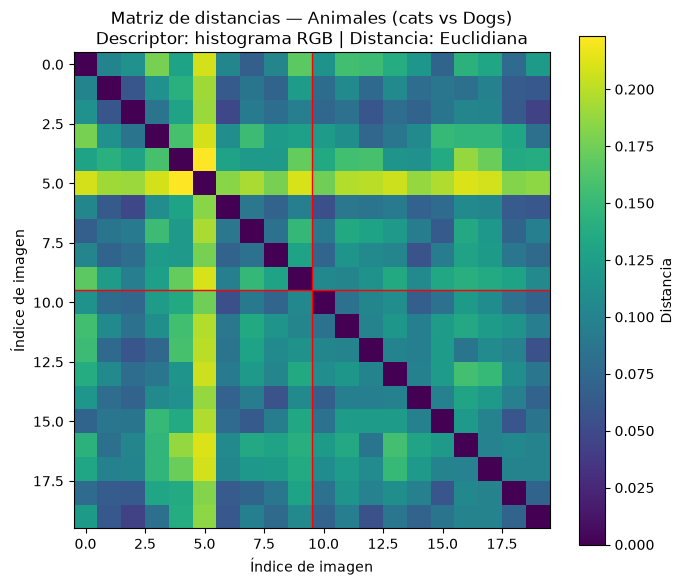

In [57]:
D_animales = matriz_distancias(descriptores_animales, distancia_euclidiana)

graficar_heatmap(D_animales, labels_animales, "Matriz de distancias — Animales (cats vs Dogs)\nDescriptor: histograma RGB | Distancia: Euclidiana")


## 6. Dataset 2. Materiales (linen / orange_peel / sandpaper / sponge)

**Descriptor elegido: histograma por zonas + variación entre vecinos (textura).**

En este dataset lo que distingue a los materiales es la **textura**, no el color (de hecho suelen ser imágenes en escala de grises). Por eso el descriptor combina:

- Un histograma de intensidades calculado por separado en 4 cuadrantes de la imagen (captura *dónde* varía la intensidad).
- Estadísticas de la diferencia entre píxeles vecinos en x e y (captura *qué tan rugosa* es la textura).

**Distancia elegida: Manhattan (L1)**, para variar respecto al primer dataset y por ser más robusta ante diferencias puntuales grandes.

In [61]:
base_materiales = os.path.join(DATA_DIR, "Materiales")
categorias_materiales = ["linen", "orange_peel", "sandpaper", "sponge"]

imgs_materiales, labels_materiales = cargar_imagenes(base_materiales, categorias_materiales, extension="png")


36 imágenes cargadas de ImagenesDescriptor/Materiales


In [64]:
def descriptor_textura(img, bins=16):
    """
    Descriptor propio para textura:
      - histograma normalizado de intensidades en cada uno de los 4 cuadrantes
      - promedio y desviación estándar de la diferencia entre píxeles vecinos (x e y)
    """
    if img.ndim == 3:  # por si viniera en RGB o RGBA
        img = color.rgb2gray(img[:, :, :3])
    else:
        img = img.astype(float)
        if img.max() > 1:  # normalizar a rango [0, 1] si venía en 0-255
            img = img / 255.0

    h, w = img.shape
    zonas = [
        img[: h // 2, : w // 2],
        img[: h // 2, w // 2 :],
        img[h // 2 :, : w // 2],
        img[h // 2 :, w // 2 :],
    ]

    def hist_norm(zona):
        hist, _ = np.histogram(zona, bins=bins, range=(0, 1))
        hist = hist.astype(float)
        return hist / hist.sum()

    hist_zonas = np.concatenate([hist_norm(z) for z in zonas])

    dx = np.abs(np.diff(img, axis=1))
    dy = np.abs(np.diff(img, axis=0))
    variacion = np.array([np.mean(dx), np.mean(dy), np.std(dx), np.std(dy)])

    return np.concatenate([hist_zonas, variacion])


descriptores_materiales = np.array([descriptor_textura(img) for img in imgs_materiales])
print("Forma de la matriz de descriptores:", descriptores_materiales.shape)


Forma de la matriz de descriptores: (36, 68)


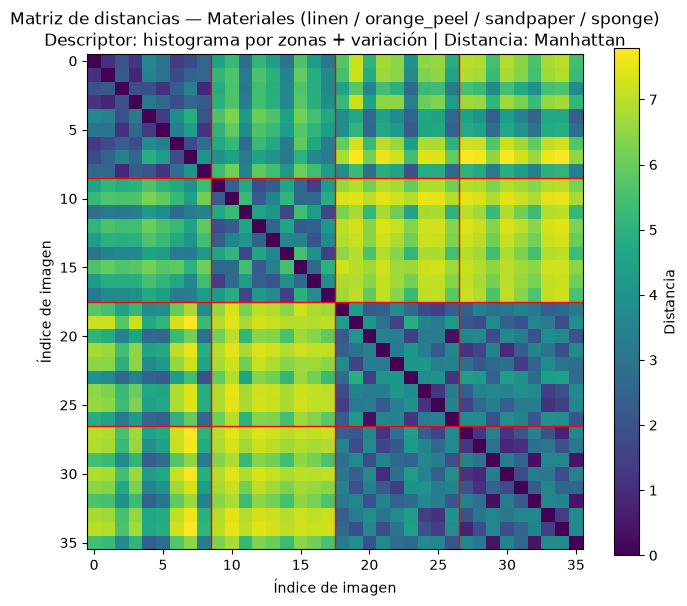

In [66]:
D_materiales = matriz_distancias(descriptores_materiales, distancia_manhattan)

graficar_heatmap(D_materiales, labels_materiales, "Matriz de distancias — Materiales (linen / orange_peel / sandpaper / sponge)\nDescriptor: histograma por zonas + variación | Distancia: Manhattan")


## 7. Conclusión

En ambos mapas de calor, si el descriptor separa bien las categorías, deberíamos ver un patrón de bloques oscuros (distancias pequeñas) a lo largo de la diagonal, correspondientes a comparaciones dentro de la misma categoría, y bloques más claros (distancias grandes) fuera de la diagonal, correspondientes a comparaciones entre categorías distintas. Esto es justamente lo que permite marcar las líneas rojas, que dividen visualmente dónde termina una clase y empieza otra.